# EDA — Jobs, Modules & Skill Pairs

Light EDA across our three processed datasets before committing to any heavy NLP work.  
Goal: understand shape, quality, and quirks so we can make informed filtering decisions.

**Datasets:**
1. `jobs_processed.csv` — job postings with descriptions, skills, salary, etc.
2. `cleaned_modules.csv` — NUS module catalogue  
3. `module_skill_pairs.csv` — skills extracted from module descriptions (via SkillNER)

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

%matplotlib inline
plt.rcParams["figure.dpi"] = 130
sns.set_style("whitegrid")

---
## Part 1: Jobs Dataset (`jobs_processed.csv`)

In [40]:
jobs = pd.read_csv("../data/processed/jobs_processed.csv")
print(f"Shape: {jobs.shape[0]:,} rows x {jobs.shape[1]} cols")
jobs.head(2)

Shape: 22,720 rows x 12 cols


,job_id,title,clean_description,job_text,skills_list,minimum_years_experience,ssoc_code,category,salary_min,salary_max,salary_avg,posting_date
0,0f754b51f0e412570c88adf9ecc0e872,"Assistant Manager, Corporate Communications","Job Summary:\r\nThis role supports the Corporate Communications team in the areas of publicity, ...","Assistant Manager, Corporate Communications. Job Summary:\r\nThis role supports the Corporate Co...","Multimedia, Social Media, Strategic Communications, Marketing, Event Management, Public Relation...",3,24320,Marketing / Public Relations,5500,7500,6500.0,29/1/2026
1,705309ff2a8d68b7ee215b6e2fc420ab,Manager (Facilities Management),Role Overview\r\nWe are seeking a Facilities Management Manager to oversee and optimise faciliti...,Manager (Facilities Management). Role Overview\r\nWe are seeking a Facilities Management Manager...,"Fire Safety, Management Skills, Sustainability, Property Management, Business Continuity, Consol...",8,12191,Real Estate / Property Management,7000,9000,8000.0,30/1/2026


### 1.1 Nulls, types & duplicates

In [41]:
# what's missing and how badly
info_df = pd.DataFrame({
    "dtype": jobs.dtypes,
    "non_null": jobs.notnull().sum(),
    "null_pct": (jobs.isnull().mean() * 100).round(2),
    "n_unique": jobs.nunique()
})
print(info_df, "\n")

# duplicate job_ids = data pipeline issue
dupes_id = jobs.duplicated(subset=["job_id"]).sum()
# duplicate descriptions = same posting scraped twice w/ different id
dupes_text = jobs.duplicated(subset=["clean_description"]).sum()
print(f"Duplicate job_ids: {dupes_id}")
print(f"Duplicate descriptions (exact): {dupes_text}")

                            dtype  non_null  null_pct  n_unique
job_id                     object     22720       0.0     22720
title                      object     22720       0.0     14985
clean_description          object     22720       0.0     16962
job_text                   object     22720       0.0     18795
skills_list                object     22720       0.0     16405
minimum_years_experience    int64     22720       0.0        22
ssoc_code                   int64     22720       0.0       664
category                   object     22720       0.0        43
salary_min                  int64     22720       0.0       385
salary_max                  int64     22720       0.0       461
salary_avg                float64     22720       0.0       727
posting_date               object     22720       0.0         7 

Duplicate job_ids: 0
Duplicate descriptions (exact): 5758


### 1.2 Category distribution
If we're classifying or filtering by category, class balance matters a lot.

Total categories: 43

Top 10:
category
Building and Construction           2138
Engineering                         2134
Customer Service                    1701
Information Technology              1699
Admin / Secretarial                 1622
Accounting / Auditing / Taxation    1233
F&B                                 1229
Marketing / Public Relations        1045
Education and Training               957
Banking and Finance                  898
Name: count, dtype: int64

Bottom 5 (candidates for merging/dropping):
category
Telecommunications        17
Travel / Tourism          14
Precision Engineering     13
Risk Management           13
Public / Civil Service     7
Name: count, dtype: int64



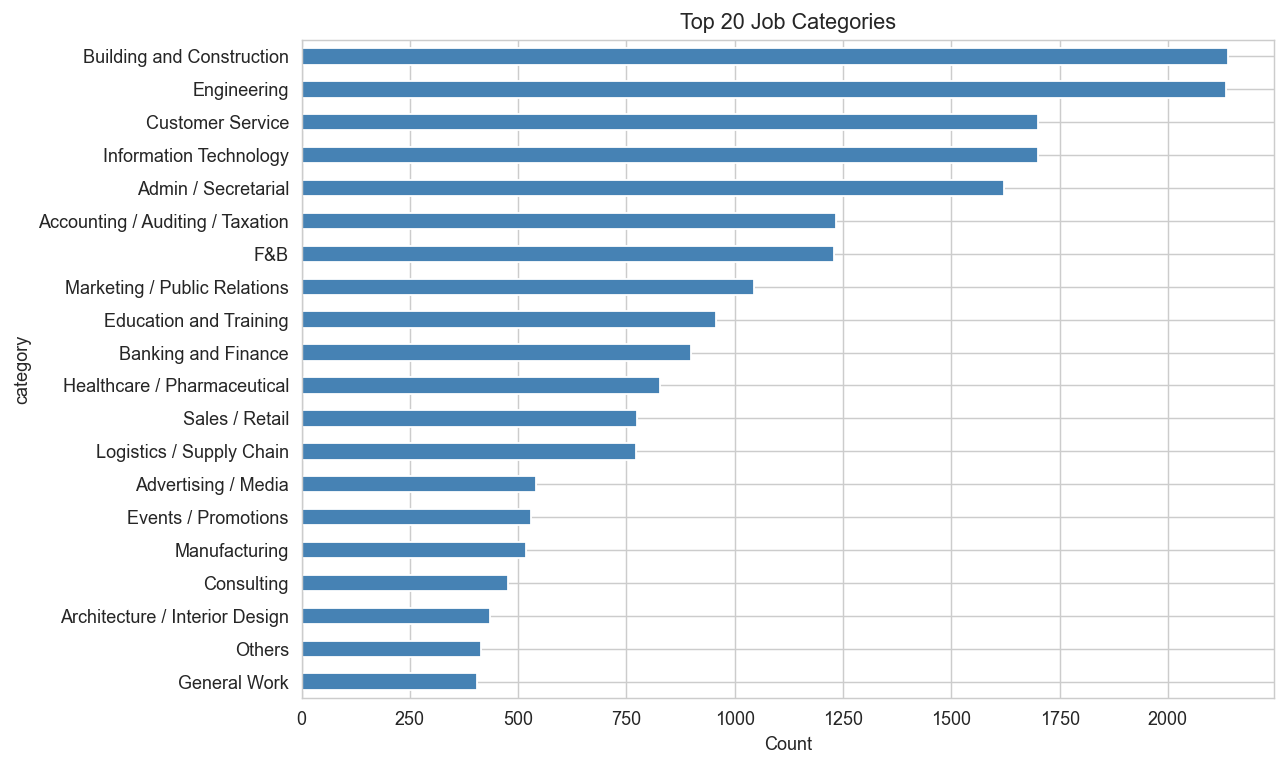

In [42]:
cat_counts = jobs["category"].value_counts()
print(f"Total categories: {cat_counts.shape[0]}\n")
print(f"Top 10:\n{cat_counts.head(10)}\n")
print(f"Bottom 5 (candidates for merging/dropping):\n{cat_counts.tail(5)}\n")

fig, ax = plt.subplots(figsize=(10, 6))
cat_counts.head(20).plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Top 20 Job Categories")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.3 Text field lengths
This drives model choice — BERT truncates at 512 tokens, so if descriptions are way longer
we either need a long-context model or some summarisation step.

In [43]:
text_cols = ["title", "clean_description", "job_text"]

for col in text_cols:
    wc = jobs[col].dropna().str.split().str.len()
    print(f"{col:25s} | median: {wc.median():>5.0f}  mean: {wc.mean():>5.0f}  "
          f"p95: {wc.quantile(0.95):>6.0f}  max: {wc.max():>6.0f}")

title                     | median:     4  mean:     5  p95:     11  max:     28
clean_description         | median:   206  mean:   243  p95:    541  max:   2294
job_text                  | median:   211  mean:   249  p95:    546  max:   2307


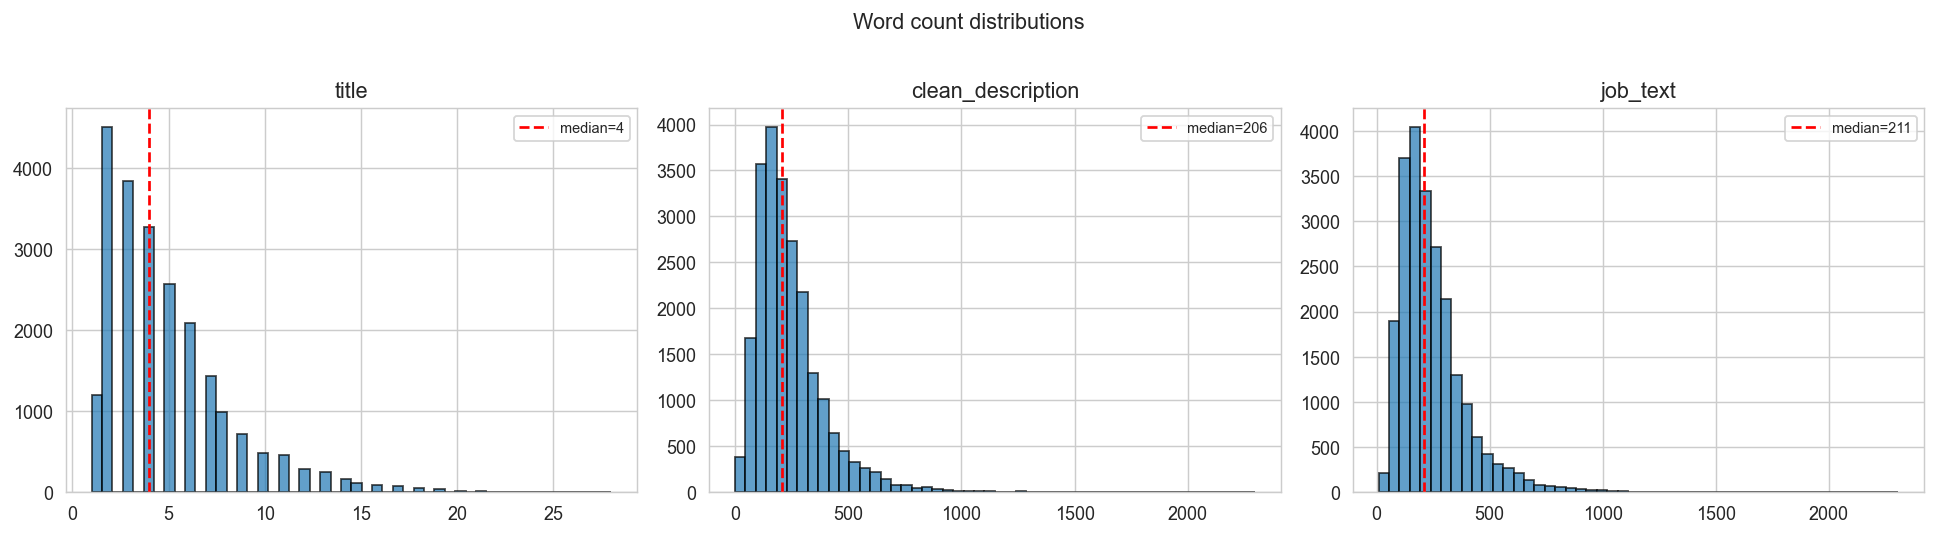

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, text_cols):
    wc = jobs[col].dropna().str.split().str.len()
    ax.hist(wc, bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(wc.median(), color="red", ls="--", label=f"median={wc.median():.0f}")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle("Word count distributions", y=1.02)
plt.tight_layout()
plt.show()

### 1.4 `clean_description` vs `job_text` — redundancy check
If these are nearly identical we can drop one and halve the text we need to process.

In [45]:
# sample to avoid slow string comparisons on full dataset
sample = jobs[["clean_description", "job_text"]].dropna().sample(
    min(1000, len(jobs)), random_state=42
)
exact_pct = (sample["clean_description"] == sample["job_text"]).mean() * 100

# even if not exact, how close are they length-wise?
ratio = sample["clean_description"].str.len() / sample["job_text"].str.len()
print(f"Exact match: {exact_pct:.1f}%")
print(f"Length ratio (clean_desc / job_text) — mean: {ratio.mean():.3f}, median: {ratio.median():.3f}")
print("\n→ If ratio ≈ 1 and exact match is high, just pick one and move on.")

Exact match: 0.0%
Length ratio (clean_desc / job_text) — mean: 0.964, median: 0.977

→ If ratio ≈ 1 and exact match is high, just pick one and move on.


### 1.5 Skills column
These are pre-extracted from job descriptions. Need to understand cardinality, coverage,
and how many are too rare to be useful.

In [46]:
skills_split = jobs["skills_list"].dropna().str.split(", ")
skills_per_job = skills_split.str.len()

print(f"Jobs with skills: {skills_split.shape[0]:,} / {len(jobs):,} "
      f"({skills_split.shape[0]/len(jobs)*100:.1f}%)")
print(f"Skills per job — median: {skills_per_job.median():.0f}, "
      f"mean: {skills_per_job.mean():.1f}, max: {skills_per_job.max():.0f}\n")

all_skills = [s.strip() for sublist in skills_split for s in sublist]
skill_freq = Counter(all_skills)

print(f"Unique skills: {len(skill_freq):,}")
singletons = sum(1 for v in skill_freq.values() if v == 1)
rare = sum(1 for v in skill_freq.values() if v <= 5)
print(f"Singletons (appear once): {singletons} ({singletons/len(skill_freq)*100:.1f}%)")
print(f"Rare (≤5 occurrences): {rare} ({rare/len(skill_freq)*100:.1f}%)")

Jobs with skills: 22,720 / 22,720 (100.0%)
Skills per job — median: 15, mean: 14.7, max: 22

Unique skills: 9,498
Singletons (appear once): 2965 (31.2%)
Rare (≤5 occurrences): 6028 (63.5%)


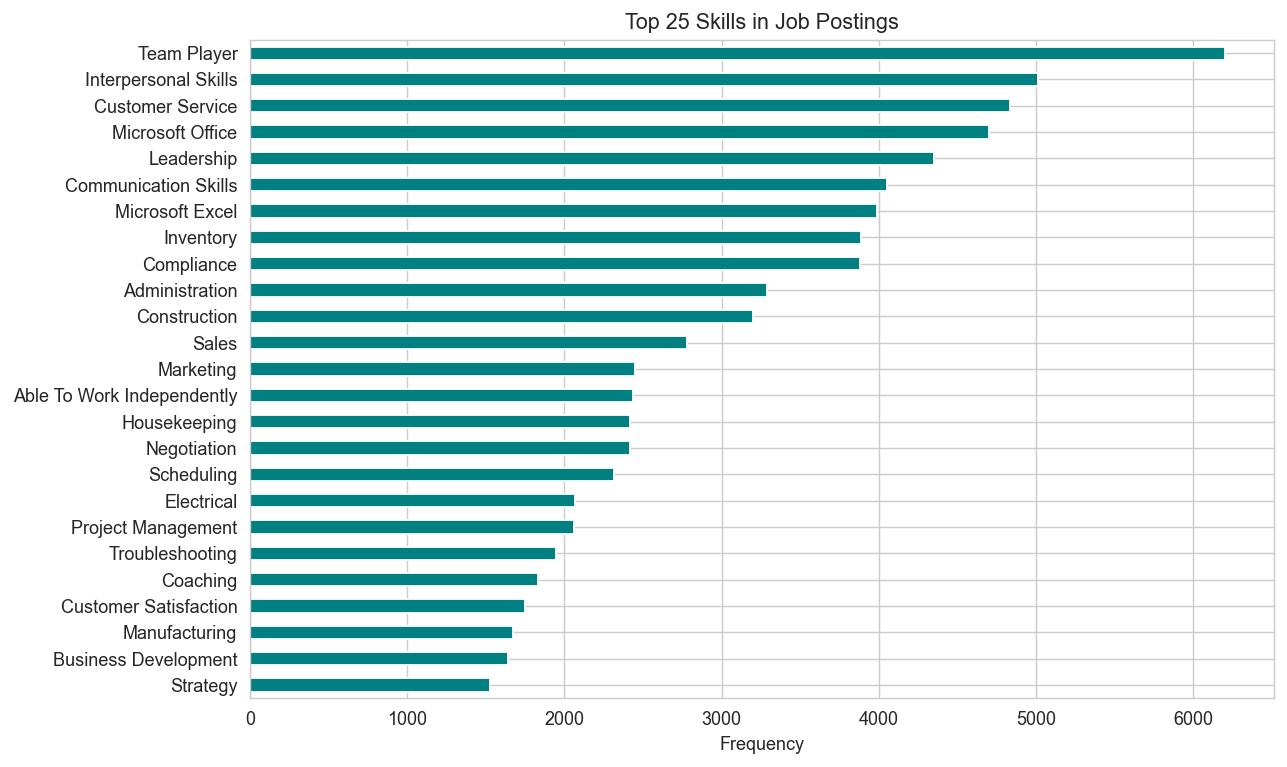

In [47]:
# top skills — these will dominate any TF-IDF or embedding
top_skills = pd.Series(dict(skill_freq.most_common(25)))
fig, ax = plt.subplots(figsize=(10, 6))
top_skills.plot.barh(ax=ax, color="teal")
ax.set_xlabel("Frequency")
ax.set_title("Top 25 Skills in Job Postings")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.6 Salary sanity check

In [48]:
print(jobs[["salary_min", "salary_max", "salary_avg"]].describe().round(0))
print(f"\nsalary_avg < 1000 (placeholder?): {(jobs['salary_avg'] < 1000).sum()}")
print(f"salary_avg > 50000 (outlier?): {(jobs['salary_avg'] > 50000).sum()}")

       salary_min  salary_max  salary_avg
count     22720.0     22720.0     22720.0
mean       3976.0      5782.0      4879.0
std        2637.0      4423.0      3426.0
min           1.0         1.0         1.0
25%        2600.0      3500.0      3150.0
50%        3200.0      4800.0      4000.0
75%        4500.0      6500.0      5500.0
max      108600.0    163000.0    135800.0

salary_avg < 1000 (placeholder?): 346
salary_avg > 50000 (outlier?): 7


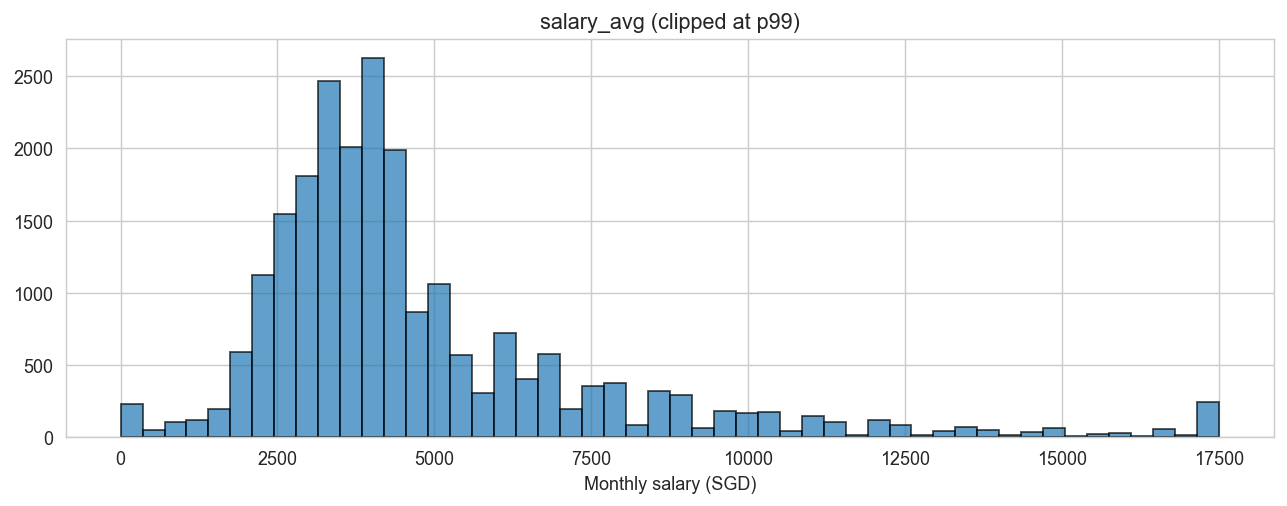

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))
jobs["salary_avg"].dropna().clip(upper=jobs["salary_avg"].quantile(0.99)).hist(
    bins=50, ax=ax, edgecolor="black", alpha=0.7
)
ax.set_title("salary_avg (clipped at p99)")
ax.set_xlabel("Monthly salary (SGD)")
plt.tight_layout()
plt.show()

### 1.7 Experience requirements

In [50]:
print(jobs["minimum_years_experience"].describe())
print(f"\nTop values:\n{jobs['minimum_years_experience'].value_counts().head(10)}")

count    22720.000000
mean         2.583363
std          2.558769
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         30.000000
Name: minimum_years_experience, dtype: float64

Top values:
minimum_years_experience
1     5368
2     4186
0     4109
3     3544
5     2844
4      650
8      601
10     563
6      416
7      224
Name: count, dtype: int64


### 1.8 Posting dates

In [51]:
jobs["posting_date"].value_counts()

posting_date
28/1/2026    4594
26/1/2026    4224
30/1/2026    4099
27/1/2026    3869
29/1/2026    3838
31/1/2026    1270
25/1/2026     826
Name: count, dtype: int64

In [52]:
daily_counts = (
    jobs.set_index("posting_date")
        .resample("D")
        .size()
)
daily_counts.plot(figsize=(10,4))
plt.xticks(rotation=45)
plt.title("Postings per day (EDA only)")
plt.show()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

### 1.9 SSOC codes

In [ ]:
print(f"Unique SSOC codes: {jobs['ssoc_code'].nunique()}")
print(f"\nTop 10:\n{jobs['ssoc_code'].value_counts().head(10)}")

Unique SSOC codes: 664

Top 10:
ssoc_code
12211    977
21499    653
33229    638
33499    610
41101    586
12199    495
75000    463
25121    402
24252    394
12222    387
Name: count, dtype: int64


---
## Part 2: Modules Dataset (`cleaned_modules.csv`)

NUS module catalogue — this is the "supply side" of skills we want to match against job demand.

In [ ]:
modules = pd.read_csv("../data/processed/cleaned_modules.csv")
print(f"Shape: {modules.shape[0]:,} rows x {modules.shape[1]} cols")
modules.head(3)

Shape: 15,845 rows x 5 cols


,module code,title,description,department,faculty
0,ABM5001,Leadership in Biomedicine,Leadership is fundamental to the success of individuals and organizations. As you progress in yo...,NUS Medicine Dean's Office,Yong Loo Lin Sch of Medicine
1,ABM5002,Advanced Biostatistics for Research,"This course serves as a concept-based introduction to biostatistics , focusing on the use of num...",NUS Medicine Dean's Office,Yong Loo Lin Sch of Medicine
2,ABM5003,Biomedical Innovation & Enterprise,This course will furnish students with a thorough understanding of a bio-venture from research a...,NUS Medicine Dean's Office,Yong Loo Lin Sch of Medicine


### 2.1 Basics

In [ ]:
info_m = pd.DataFrame({
    "dtype": modules.dtypes,
    "non_null": modules.notnull().sum(),
    "null_pct": (modules.isnull().mean() * 100).round(2),
    "n_unique": modules.nunique()
})
print(info_m, "\n")

# are there duplicate module codes? (e.g. ACC1701, ACC1701A, ACC1701B...)
# these are different sections of the same course
print(f"Unique module codes: {modules['module code'].nunique()}")
print(f"Unique titles: {modules['title'].nunique()}")

# how many codes map to the same title? this tells us about variant sections
title_groups = modules.groupby("title")["module code"].count()
multi = title_groups[title_groups > 1]
print(f"\nTitles with multiple codes (variants/sections): {len(multi)}")
print(f"Example: '{multi.idxmax()}' has {multi.max()} variants")

              dtype  non_null  null_pct  n_unique
module code  object     15845       0.0     15845
title        object     15845       0.0     10254
description  object     15845       0.0     11176
department   object     15845       0.0       100
faculty      object     15845       0.0        25 

Unique module codes: 15845
Unique titles: 10254

Titles with multiple codes (variants/sections): 2537
Example: 'Independent Study' has 93 variants


### 2.2 Faculty & department coverage
Tells us which parts of NUS are represented — important if we only care about
certain faculties for the matching task.

Faculties: 25
Departments: 100



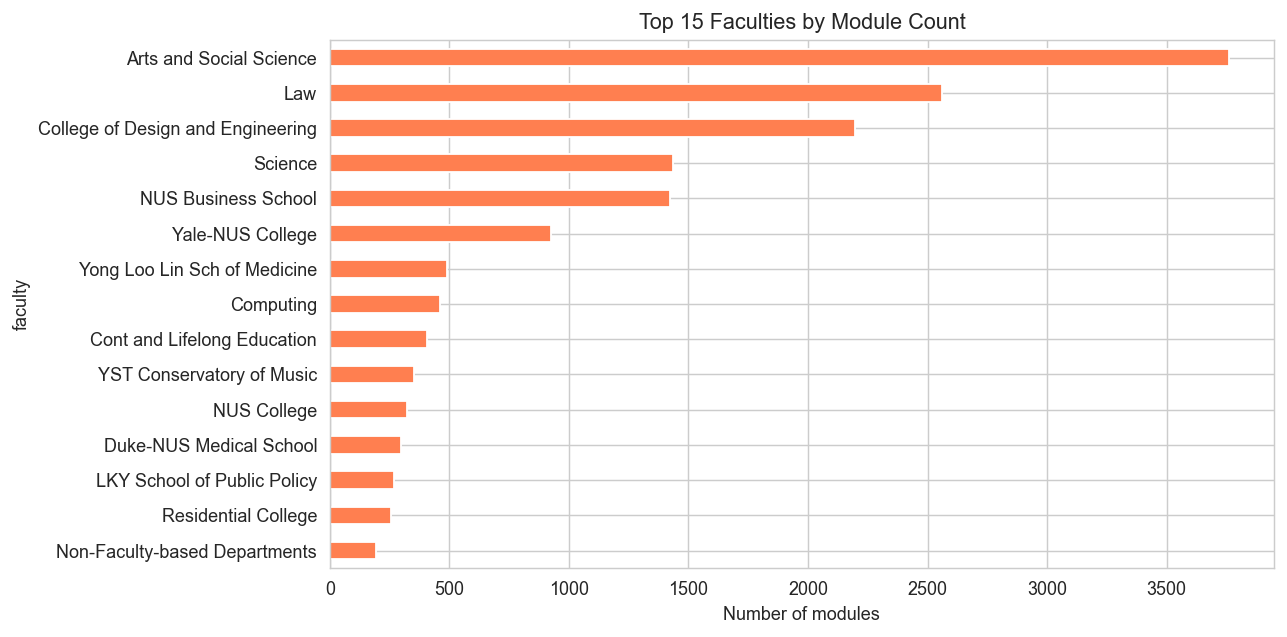

In [ ]:
print(f"Faculties: {modules['faculty'].nunique()}")
print(f"Departments: {modules['department'].nunique()}\n")

fac_counts = modules["faculty"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
fac_counts.head(15).plot.barh(ax=ax, color="coral")
ax.set_xlabel("Number of modules")
ax.set_title("Top 15 Faculties by Module Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 2.3 Description text lengths
Same reasoning as jobs — need to know how long these are for NLP.

Description word count — median: 89, mean: 85, p95: 130, max: 328


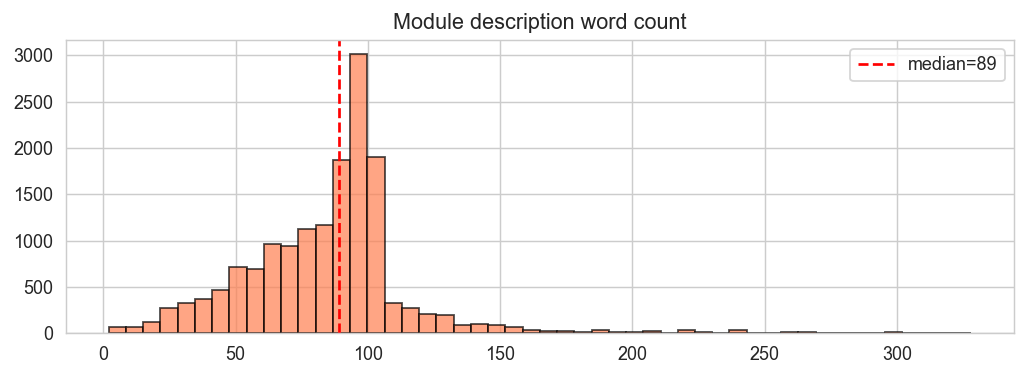

In [ ]:
desc_wc = modules["description"].dropna().str.split().str.len()
print(f"Description word count — median: {desc_wc.median():.0f}, "
      f"mean: {desc_wc.mean():.0f}, p95: {desc_wc.quantile(0.95):.0f}, "
      f"max: {desc_wc.max():.0f}")

fig, ax = plt.subplots(figsize=(8, 3))
desc_wc.hist(bins=50, ax=ax, edgecolor="black", alpha=0.7, color="coral")
ax.axvline(desc_wc.median(), color="red", ls="--", label=f"median={desc_wc.median():.0f}")
ax.set_title("Module description word count")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Module code prefixes → academic level
The prefix letters hint at the department, and the first digit usually indicates
the level (1xxx=Y1, 5xxx/6xxx=grad). Let's see the distribution.

Module level distribution:
level
1.0     977
2.0    2074
3.0    2490
4.0    3371
5.0    5564
6.0    1356
8.0       7
9.0       6
Name: count, dtype: int64


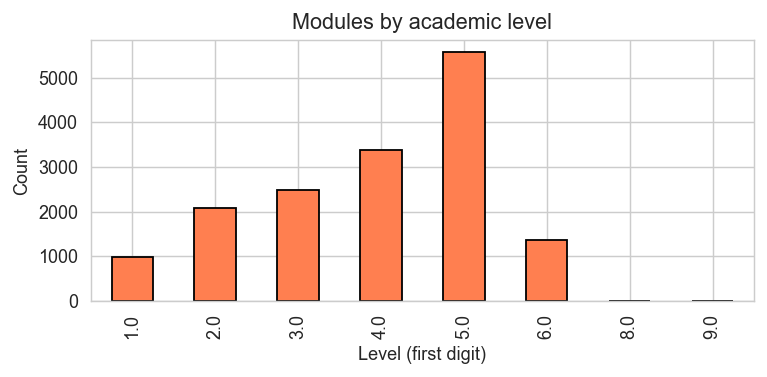

In [ ]:
# extract the numeric level from module code (first digit of the number part)
modules["level"] = modules["module code"].str.extract(r"(\d)")[0].astype(float)

level_counts = modules["level"].value_counts().sort_index()
print("Module level distribution:")
print(level_counts)

fig, ax = plt.subplots(figsize=(6, 3))
level_counts.plot.bar(ax=ax, color="coral", edgecolor="black")
ax.set_xlabel("Level (first digit)")
ax.set_ylabel("Count")
ax.set_title("Modules by academic level")
plt.tight_layout()
plt.show()

### 2.5 Duplicate descriptions
Some modules are clearly the same course offered under different codes.
If we're embedding descriptions, exact dupes just waste compute.

In [ ]:
desc_dupes = modules.duplicated(subset=["description"]).sum()
print(f"Exact duplicate descriptions: {desc_dupes} "
      f"({desc_dupes/len(modules)*100:.1f}% of all modules)")

# after deduplication, how many unique modules do we actually have?
unique_desc = modules.drop_duplicates(subset=["description"])
print(f"Unique descriptions: {unique_desc.shape[0]}")

Exact duplicate descriptions: 4669 (29.5% of all modules)
Unique descriptions: 11176


---
## Part 3: Module–Skill Pairs (`module_skill_pairs.csv`)

Skills extracted from module descriptions via SkillNER. This bridges modules to jobs.

> **Note:** If the columns here look identical to `cleaned_modules`, double-check the
> file — it might have been overwritten or the wrong file was committed. The expected
> schema would have at minimum a `skill` or `extracted_skill` column.

In [ ]:
pairs = pd.read_csv("../data/processed/module_skill_pairs.csv")
print(f"Shape: {pairs.shape[0]:,} rows x {pairs.shape[1]} cols")
print(f"Columns: {list(pairs.columns)}\n")
pairs.head(5)

Shape: 99,411 rows x 3 cols
Columns: ['module code', 'title', 'skill']



,module code,title,skill
0,ABM5001,Leadership in Biomedicine,leadership
1,ABM5001,Leadership in Biomedicine,biomedicine
2,ABM5002,Advanced Biostatistics for Research,medical research
3,ABM5002,Advanced Biostatistics for Research,statistical method
4,ABM5002,Advanced Biostatistics for Research,biostatistics


### 3.1 Schema check & basic stats

In [ ]:
# let's inspect what we're actually working with
info_p = pd.DataFrame({
    "dtype": pairs.dtypes,
    "non_null": pairs.notnull().sum(),
    "null_pct": (pairs.isnull().mean() * 100).round(2),
    "n_unique": pairs.nunique()
})
print(info_p)

              dtype  non_null  null_pct  n_unique
module code  object     99411       0.0     15478
title        object     99411       0.0     10038
skill        object     99411       0.0     10700


Skill column(s) found: ['skill']

Total rows (module-skill pairs): 99,411
Unique modules: 15478
Unique skills: 10700

Skills per module — median: 6, mean: 6.4, max: 30

Top 20 extracted skills:
skill
research         2017
social           1356
case             1008
economic          996
e                 787
management        687
perspective       639
writing           498
economics         471
lectures          424
readings          397
investment        381
economy           378
planning          368
communication     357
innovation        352
urban             341
debates           319
reading           319
analytical        319
Name: count, dtype: int64


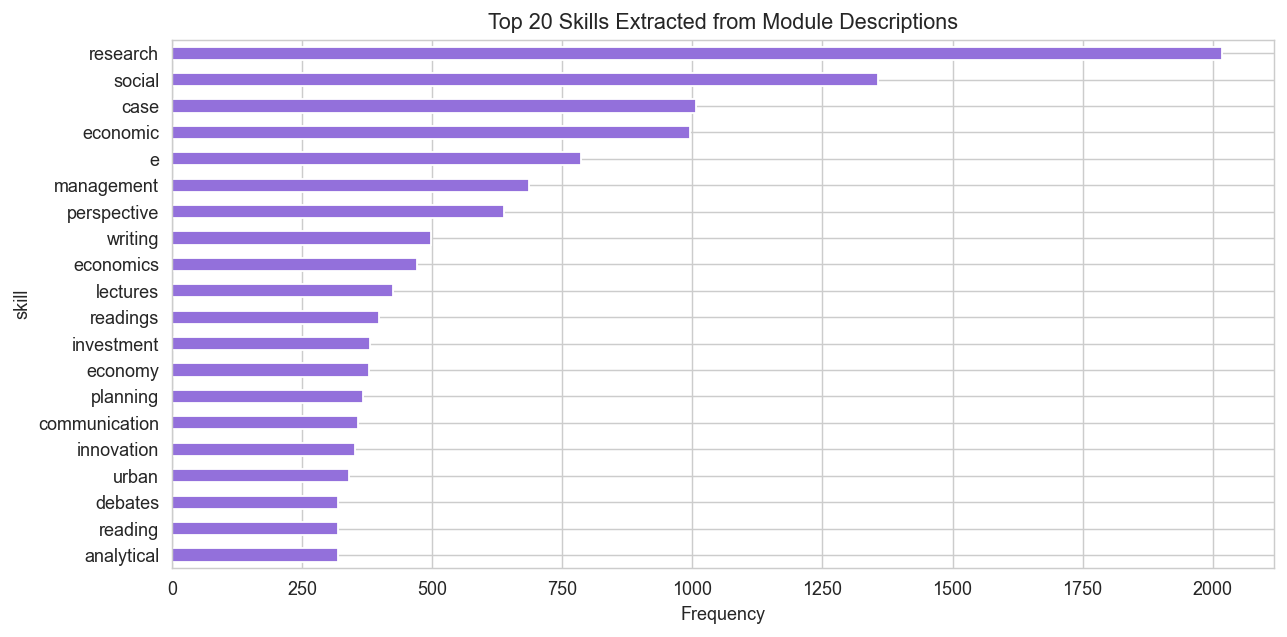


Singleton skills (appear in 1 module only): 3990 (37.3%)


In [ ]:
# ── The rest of this section adapts to whatever columns are present ──
# If there's a skill column, great — we analyze it.
# If it's the same as cleaned_modules, we flag it and move on.

skill_cols = [c for c in pairs.columns if "skill" in c.lower()]

if skill_cols:
    print(f"Skill column(s) found: {skill_cols}")
    skill_col = skill_cols[0]  # take the first one
    
    print(f"\nTotal rows (module-skill pairs): {len(pairs):,}")
    print(f"Unique modules: {pairs['module code'].nunique()}")
    print(f"Unique skills: {pairs[skill_col].nunique()}")
    
    # skills per module
    spm = pairs.groupby("module code")[skill_col].count()
    print(f"\nSkills per module — median: {spm.median():.0f}, "
          f"mean: {spm.mean():.1f}, max: {spm.max()}")
    
    # most common extracted skills
    top_module_skills = pairs[skill_col].value_counts().head(20)
    print(f"\nTop 20 extracted skills:\n{top_module_skills}")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    top_module_skills.plot.barh(ax=ax, color="mediumpurple")
    ax.set_xlabel("Frequency")
    ax.set_title("Top 20 Skills Extracted from Module Descriptions")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # singleton skills — too rare to match reliably
    mod_skill_freq = pairs[skill_col].value_counts()
    singletons_m = (mod_skill_freq == 1).sum()
    print(f"\nSingleton skills (appear in 1 module only): {singletons_m} "
          f"({singletons_m/len(mod_skill_freq)*100:.1f}%)")

else:
    print("⚠️  No skill column found in module_skill_pairs.csv")
    print(f"   Columns present: {list(pairs.columns)}")
    print("   This looks identical to cleaned_modules — check with your teammate")
    print("   whether the right file was exported from the SkillNER pipeline.")
    print()
    print("   Expected something like: module_code | skill | [confidence]")

---
## Part 4: Cross-dataset checks

Quick sanity checks on how the datasets relate to each other.

In [ ]:
# ── Skill vocabulary overlap ──
# If module skills and job skills use totally different vocabularies,
# direct matching won't work and we'll need embeddings or a taxonomy

job_skills_set = set(s.strip().lower() for sublist in 
                     jobs["skills_list"].dropna().str.split(", ") for s in sublist)

if skill_cols:
    mod_skills_set = set(pairs[skill_col].dropna().str.strip().str.lower())
    
    overlap = job_skills_set & mod_skills_set
    print(f"Job skills vocab:    {len(job_skills_set):,}")
    print(f"Module skills vocab: {len(mod_skills_set):,}")
    print(f"Overlap:             {len(overlap):,} "
          f"({len(overlap)/min(len(job_skills_set), len(mod_skills_set))*100:.1f}% "
          f"of the smaller set)")
    print(f"\nSample overlapping skills: {sorted(list(overlap))[:15]}")
    print(f"\nJob-only skills (sample): {sorted(list(job_skills_set - mod_skills_set))[:10]}")
    print(f"Module-only skills (sample): {sorted(list(mod_skills_set - job_skills_set))[:10]}")
else:
    print("Skipping skill overlap check — no skill column in module_skill_pairs.")
    print(f"Job skills vocab size: {len(job_skills_set):,}")

Job skills vocab:    9,492
Module skills vocab: 10,689
Overlap:             1,670 (17.6% of the smaller set)

Sample overlapping skills: ['3d modeling', '3d modelling', '3d visualization', 'access control', 'accident prevention', 'accountability', 'accounting', 'accounting standards', 'accounting system', 'acoustics', 'act', 'action research', 'active learning', 'active listening', 'actuarial science']

Job-only skills (sample): ['.net', '.net core', '1st and 2nd level helpdesk', '24/7 operations', '2d production drawings', '360 degree marketing', '3d', '3d animation', '3d drawings', '3d rendering']
Module-only skills (sample): ['2d', '2d animation', '3d computer graphic', '3d design', '3d graphics', '3d model', '3d printed', '3d printing', '3d reconstruction', ';']


---
## Summary & Next Steps

Run through the outputs above and fill in:

| Question | Answer |
|---|---|
| Jobs to drop (text dupes)? | _check 1.1_ |
| Can we drop `job_text` or `clean_description`? | _check 1.4_ |
| Categories to merge/drop (rare classes)? | _check 1.2_ |
| Max text length → model choice? | _check 1.3 & 2.3_ |
| Skill vocab overlap sufficient for matching? | _check Part 4_ |
| Module dedup needed before embedding? | _check 2.5_ |
| `module_skill_pairs.csv` usable as-is? | _check 3.1_ |
